
# This notebook documents the efforts to fix some issues in the previous notebook named "ego_could_practice" that generated a wordloud that failed to capture the negative words in phrases, such as "don't want"

# Ego-network: count PHRASES near `data center` ; a data center planned in a town called East Fishkill faced backlash

This notebook finds words/phrases that often appear near `data center` or `data centers` in the transcript text.

The idea is simple:

1. Find the target phrase.
2. Take a context window around it.
3. Remove stopwords, words that are used frequently but carry no meaning in this analsysis, such as "things", "will" or "applause".
4. Count the most common nearby words/phrases.
5. **find examples/quotes for the story based on the findings

In [1]:
# setting up tools I need

import re #regular expressions
from collections import Counter #pip install collections

import pandas as pd
import nltk #natural language toolkit
from nltk.corpus import stopwords

## 1. Load the transcripts

The CSV does not have a column literally named `text`. The transcript text is in `Full Text`, so we use that column.

In [2]:
df = pd.read_csv("town_board_transcripts.csv")
df.head()

,Month,Meeting Title,Full Text
0,March,Town Board Meeting,good evening everyone. thanks for joining us. ...
1,May,Town Board Meeting,"good evening, everyone. thanks for joining us...."
2,May,Town Board Meeting,good evening everyone. thanks for joining us. ...
3,June,Town Board Meeting,"good evening. good evening, everyone. thanks f..."


In [3]:
texts = df["Full Text"].dropna().astype(str).tolist()

#dropna() to remove any rows with missing values in the "Full Text" column, and astype(str) to ensure that all entries are treated as strings. 
#Finally, we convert the resulting Series to a list using tolist() to get a list of all the transcripts.

print(f"Number of transcripts: {len(texts)}")


Number of transcripts: 4


In [4]:
# addressing the issue of "disappearing apostrophes" in the text data. I'll try with code first but if that doesn't work, I can also try to fix it in the original CSV file mannually.
import re

# Each pattern matches the "broken" version (space where the apostrophe
# should be), each value is what it should actually be.
CONTRACTION_FIXES = {
    r"\bi m\b": "i'm", r"\bi ve\b": "i've", r"\bi d\b": "i'd", r"\bi ll\b": "i'll",
    r"\byou re\b": "you're", r"\byou ve\b": "you've", r"\byou d\b": "you'd", r"\byou ll\b": "you'll",
    r"\bwe re\b": "we're", r"\bwe ve\b": "we've", r"\bwe d\b": "we'd", r"\bwe ll\b": "we'll",
    r"\bthey re\b": "they're", r"\bthey ve\b": "they've", r"\bthey d\b": "they'd", r"\bthey ll\b": "they'll",
    r"\bthat s\b": "that's", r"\bit s\b": "it's", r"\bwhat s\b": "what's",
    r"\bthere s\b": "there's", r"\bhere s\b": "here's", r"\bhe s\b": "he's",
    r"\bshe s\b": "she's", r"\bwho s\b": "who's", r"\blet s\b": "let's",
    r"\bdon t\b": "don't", r"\bdoesn t\b": "doesn't", r"\bdidn t\b": "didn't",
    r"\bcan t\b": "can't", r"\bcouldn t\b": "couldn't", r"\bwon t\b": "won't",
    r"\bwouldn t\b": "wouldn't", r"\bshouldn t\b": "shouldn't",
    r"\bisn t\b": "isn't", r"\baren t\b": "aren't", r"\bwasn t\b": "wasn't",
    r"\bweren t\b": "weren't", r"\bhasn t\b": "hasn't", r"\bhaven t\b": "haven't",
    r"\bhadn t\b": "hadn't",
}

def fix_broken_apostrophes(text):
    for pattern, replacement in CONTRACTION_FIXES.items():
        text = re.sub(pattern, replacement, text)
    return text

# Apply it to your dataframe
df["Full Text"] = df["Full Text"].apply(fix_broken_apostrophes)
texts = df["Full Text"].tolist()

## 2. Load NLTK stopwords

Stopwords are common words like `the`, `is`, `and`, and `a`. They usually appear often, but they are not very meaningful for this kind of word-neighborhood analysis.

In [5]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\liyan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words("english"))

In [7]:
nltk.download("stopwords", quiet=True) # quiet=True to suppress output during download

stop_words = set(stopwords.words("english"))

#can also add custom stopwords to the set if needed, for example:
#custom_stopwords = {"data", "center", "centers"}
#stop_words.update(custom_stopwords)

stop_words.update({"something", "also", "could", "applause", "lot", "would", "things", "many", "much", "okay", "say", "think", "know", "like", "right", "yeah", "well", "um", "uh", "got", "get", "going", "going to", "gonna"})

# *** KEEP "don't", "not", "no"
words_to_keep = {"don't", "not", "no", "against"}
custom_stopwords = stop_words - words_to_keep
print(f"Number of stopwords: {len(custom_stopwords)}")
list(sorted(custom_stopwords))[:20]


Number of stopwords: 218


['a',
 'about',
 'above',
 'after',
 'again',
 'ain',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'applause',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because']

## 3. Choose the target phrase and window size

`window_size = 40` means we take up to 40 words before the phrase and 40 words after the phrase. 
#how many words before and after the target phrase to include in the context window
#At a local board meeting, residents are usually given a strict 3-minute limit to speak at the public microphone.
#By setting  window size to 100, the script is capturing roughly half of a person's entire public comment every time they mention "data center." 

In [8]:
target_phrases = {"data center", "data centers"}
window_size = 60

## 4. Count nearby words--**PHRASES

This is the main ego-network step. Every time the target phrase appears, we collect words nearby and count them.
1. find every target phrase in the texts
2. count 10 words before and after
3. group the words and count them

In [9]:
# 1. Rebuild texts fresh, just to be safe
texts = df["Full Text"].tolist()
# 2. Re-run the FULL co_terms counting cell -- the whole block,
#    starting from co_terms = Counter(), not just part of it
co_terms = Counter()
examples = []
matches = 0

target_words = {"data", "center", "centers"}
target_words.update({"east", "fishkill"})

for text in texts:
    words = re.findall(r"\b[\w']+\b", text.lower())
    for i in range(len(words) - 1):
        phrase = words[i] + " " + words[i + 1]
        if phrase in target_phrases:
            matches += 1
            start = max(0, i - window_size)
            end = min(len(words), i + 2 + window_size)
            context_words = words[start:end]
            if len(examples) < 5:
                left = " ".join(words[max(0, i - 10):i])
                right = " ".join(words[i + 2:min(len(words), i + 12)])
                examples.append(f"{left} [{phrase}] {right}")
            for j, word in enumerate(context_words):
                if (
                    word.isalpha()
                    and word not in stop_words
                    and word not in target_words
                    and len(word) > 2
                ):
                    co_terms[word] += 1
                    if j > 0:
                        prev_word = context_words[j - 1]
                        bigram = f"{prev_word} {word}"
                        co_terms[bigram] += 1

print(f"Matches found: {matches}")

# 3. Now check for bigrams
bigrams_only = [item for item in co_terms.most_common(50) if " " in item[0]]
print(f"Total co_terms entries: {len(co_terms)}")
print(f"Bigram entries found: {len(bigrams_only)}")
bigrams_only

Matches found: 146
Total co_terms entries: 4999
Bigram entries found: 7


[('the town', 39),
 ('we need', 36),
 ('to make', 29),
 ('i want', 25),
 ('the community', 21),
 ('year moratorium', 20),
 ('this town', 18)]

In [10]:
# Look specifically for two-word phrases (bigrams) in the results
bigrams_only = [item for item in co_terms.most_common(50) if " " in item[0]]
bigrams_only

[('the town', 39),
 ('we need', 36),
 ('to make', 29),
 ('i want', 25),
 ('the community', 21),
 ('year moratorium', 20),
 ('this town', 18)]

In [11]:
# Pull out just the bigrams that contain a negation word
negation_words = ["don't", "doesn't", "didn't", "won't", "wouldn't", "can't", "couldn't", "not", "isn't", "aren't"]

negation_bigrams = [item for item in co_terms.most_common() if any(neg in item[0] for neg in negation_words)]
negation_bigrams

[("don't want", 14),
 ('another', 13),
 ('not allowing', 5),
 ('noticed', 5),
 ("i've noticed", 5),
 ('cannot', 4),
 ('not want', 4),
 ('not need', 4),
 ("can't put", 4),
 ('not put', 4),
 ("can't support", 4),
 ('not currently', 3),
 ("don't need", 3),
 ('not even', 3),
 ('not working', 3),
 ('not permitted', 2),
 ("doesn't allow", 2),
 ('they cannot', 2),
 ('not included', 2),
 ('not big', 2),
 ('want another', 2),
 ("didn't elaborate", 2),
 ('we cannot', 2),
 ('cannot afford', 2),
 ('not create', 2),
 ("doesn't improve", 2),
 ('not make', 2),
 ('not progression', 2),
 ('and another', 2),
 ('another fat', 2),
 ('in another', 2),
 ('another rich', 2),
 ("don't make", 2),
 ("don't generate", 2),
 ('not build', 2),
 ('build another', 2),
 ('another type', 2),
 ('or another', 2),
 ('another high', 2),
 ('note', 2),
 ('to note', 2),
 ('noted', 1),
 ('fran noted', 1),
 ("don't appreciate", 1),
 ('not wait', 1),
 ("don't see", 1),
 ('through another', 1),
 ('another pandemic', 1),
 ('not su

## trying word cloud for the first time:
Main steps: 
1. setting up tools: install wordcloud
2. show the top-words result as a table
3. an edge table, simple ego-network format: the source is the target phrase, and each target is a nearby word.
4. make the wordcloud imange using 

In [12]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [13]:
from wordcloud import WordCloud 
#***NOTE: WordCloud, the word iteself, is case senstive 

##  Show the result as a table

These are the strongest nearby words in the ego-network.

In [14]:
top_terms = pd.DataFrame(co_terms.most_common(30), columns=["word", "count"])
top_terms


,word,count
0,town,85
1,want,75
2,need,67
3,water,66
4,community,65
5,thank,64
6,make,54
7,moratorium,54
8,time,44
9,power,42


## 6. Make an edge table

This is a simple ego-network format: the source is the target phrase, and each target is a nearby word.

In [15]:
ego_edges = top_terms.rename(columns={"word": "target", "count": "weight"})
ego_edges.insert(0, "source", "data center")

ego_edges

,source,target,weight
0,data center,town,85
1,data center,want,75
2,data center,need,67
3,data center,water,66
4,data center,community,65
5,data center,thank,64
6,data center,make,54
7,data center,moratorium,54
8,data center,time,44
9,data center,power,42


## Quick check: example context windows

This helps to confirm that we are actually looking at the right phrase in the right context.

In [16]:
for example in examples:
    print(example)
    print()


to make a mention i've had several calls about a [data center] coming to east fishkill well that's news to us because

this week on that saying a huge 1 000 mw [data center] is coming to east fishkill and no i don't know

there was a property owner that wanted to put a [data center] that discussed this months ago and we told them and

power there so in order for there to be a [data center] they'd have to construct a new substation which will take

get you whatever information you need but there there's no [data center] application currently for east fishkill so okay now with that



## Try another phrase

To test another ego-network, change `target_phrases` and rerun the notebook.

To make the context wider or narrower, change `window_size`.

Data successfully backed up to 'data_center_edge_table.csv'!


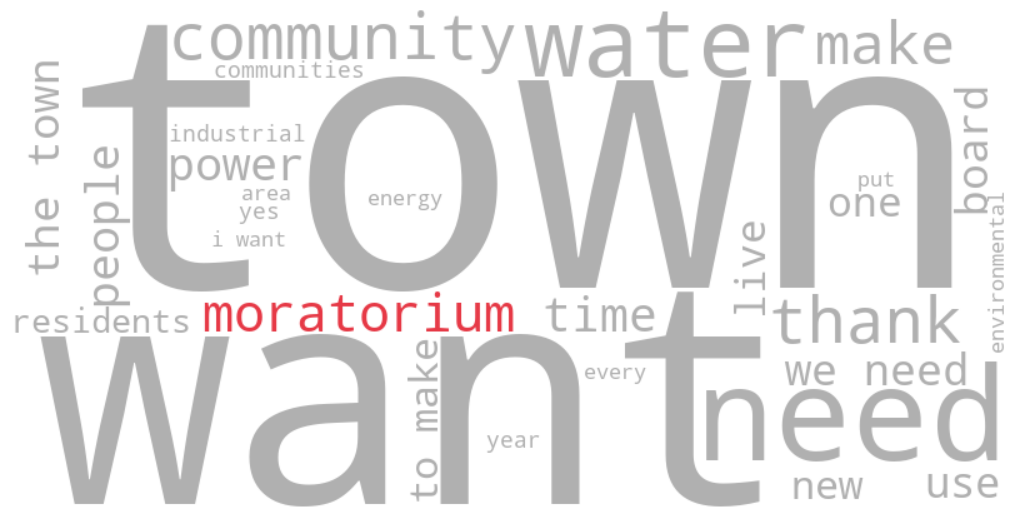

In [18]:
import matplotlib.pyplot as plt 
#matplotlib is a plotting library for creating static, animated, and interactive visualizations in Python.)

#save the table to a CSV file in your directory
# This writes your exact ego_edges dataframe to a CSV file in your directory
ego_edges.to_csv("data_center_edge_table.csv", index=False)
print("Data successfully backed up to 'data_center_edge_table.csv'!")


# Load the CSV file back into a clean processing dataframe
df_cloud = pd.read_csv("data_center_edge_table.csv")

# Convert the targets and weights columns into the required frequency dictionary
word_frequencies = dict(zip(df_cloud["target"], df_cloud["weight"]))

# Generate the Word Cloud layout image
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis",  # Clean, professional color gradient palette
    prefer_horizontal=0.9,  # Ensures words remain easily readable
).generate_from_frequencies(word_frequencies)

# Define which word(s) to highlight, and in what color. The two color lines here are just like picking the crayons: 
HIGHLIGHT_WORDS = {"moratorium"}
HIGHLIGHT_COLOR = "#e63946"   # a bold red -- change to whatever fits your story's palette
MUTED_COLOR = "#b0b0b0"       # gray for everything else

def highlight_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # WordCloud passes each word through this function one at a time --
    # we just check if it's the one we care about and return a color string
    if word.lower() in HIGHLIGHT_WORDS:
        return HIGHLIGHT_COLOR
    return MUTED_COLOR

# .recolor() reuses the SAME layout (word positions/sizes) already
# computed above -- it just swaps out the colors, so your word
# placement won't shift or change
wordcloud.recolor(color_func=highlight_color_func, random_state=42)

# Display the final graphic on your screen
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # Hides graph axis numbers to keep the visual sharp
plt.tight_layout(pad=0)
plt.show()

In [20]:
# frequency check of the key word "data center" or the "data centers" in the text data. I'm not going to overcrowd the story with another graphic. 
# just want to confirm that the word "data center" or "data centers" appears in the text data, and how many times.
# so i can mention one line or two in the story about the attention to the issue 

print(df.columns.tolist())

for _, row in df.iterrows():
    text = row["Full Text"]
    count = text.count("data center") + text.count("data centers")
    print(f"{row['Month']}: {count} mentions")

['Month', 'Meeting Title', 'Full Text']
March: 0 mentions
May: 5 mentions
May: 30 mentions
June: 195 mentions
